# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 2026-2027 — Major Project (Data Visualization)

**Objective:** Analyze agricultural data across seasons (Kharif, Rabi, Zaid) to identify meaningful patterns, trends, relationships and differences in agricultural performance, and develop evidence-based conclusions and recommendations.

**Dataset:** `seasonal_agriculture_performance_dataset.csv` — 4000 farm records across 8 states, 10 districts, 8 crops, 3 seasons, and 4 irrigation methods, covering environmental conditions, resource usage, yield and economic performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)


## 1. Data Loading and Initial Exploration

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [5]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSeasons:", df['Season'].unique())
print("States:", df['State'].nunique(), "| Districts:", df['District'].nunique(), "| Crops:", df['Crop'].nunique())


Missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0

Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
States: 8 | Districts: 10 | Crops: 8


## 2. Data Cleaning and Preparation

Steps taken:
- Handle missing values in `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha` (median imputation, grouped by Season where meaningful).
- Cap extreme outliers in `Yield_Tonnes_Ha` and `Water_Efficiency_t_per_1000m3` using the IQR method (a handful of data-entry-scale errors, e.g. yields >100 t/ha, are not physically realistic for these crops).
- Confirm categorical columns are clean and consistently labeled.


In [6]:
# Missing value treatment - median imputation grouped by Season
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [7]:
# Outlier capping (IQR method) for Yield and Water Efficiency
def cap_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    return series.clip(lower=max(lower, 0), upper=upper)

before = df['Yield_Tonnes_Ha'].max()
df['Yield_Tonnes_Ha'] = cap_outliers_iqr(df['Yield_Tonnes_Ha'])
df['Water_Efficiency_t_per_1000m3'] = cap_outliers_iqr(df['Water_Efficiency_t_per_1000m3'])
print(f"Max Yield_Tonnes_Ha before capping: {before:.2f}  ->  after: {df['Yield_Tonnes_Ha'].max():.2f}")

# Derived column: Profit Margin
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100


Max Yield_Tonnes_Ha before capping: 101.44  ->  after: 5.50


## 3. Seasonal Overview

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


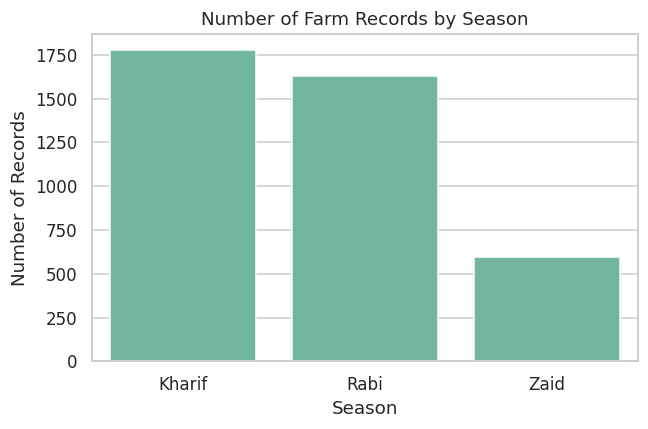

In [8]:
season_order = ['Kharif', 'Rabi', 'Zaid']
season_counts = df['Season'].value_counts().reindex(season_order)
print(season_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=season_counts.index, y=season_counts.values, order=season_order)
plt.title('Number of Farm Records by Season')
plt.ylabel('Number of Records')
plt.xlabel('Season')
plt.tight_layout()
plt.show()


**Observation:** Records are distributed across the three cropping seasons — Kharif (monsoon), Rabi (winter) and Zaid (summer) — giving a reasonably balanced basis for seasonal comparison.

## 4. Environmental Conditions Across Seasons

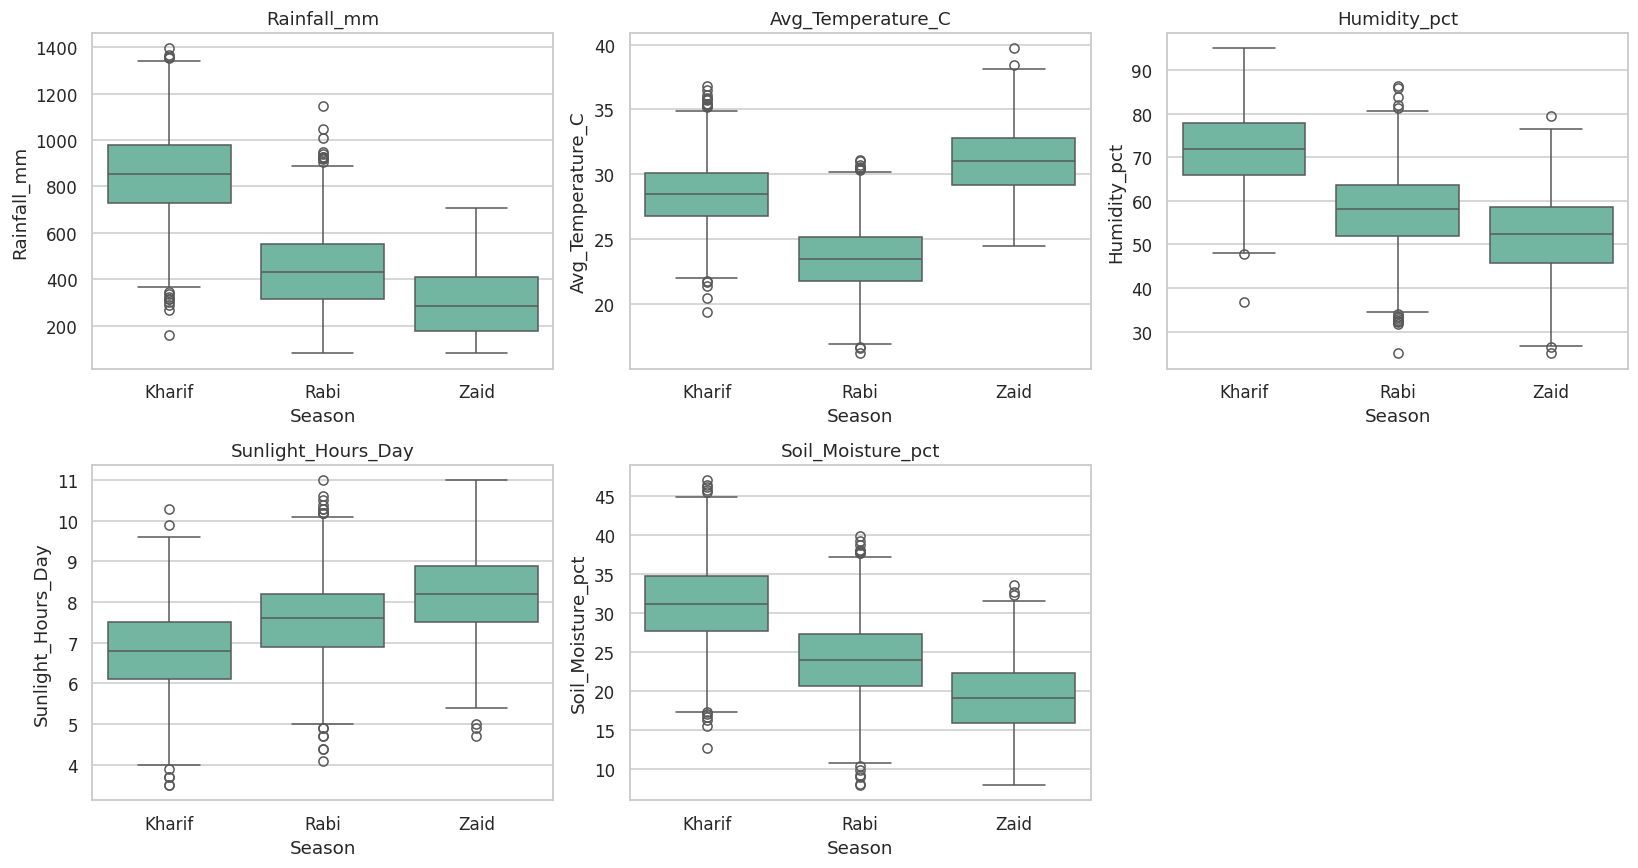

In [9]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i])
    axes[i].set_title(col)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


In [10]:
print(df.groupby('Season')[env_cols].mean().reindex(season_order).round(2))


        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_Moisture_pct
Season                                                                                     
Kharif       852.11              28.45         71.81                6.79              31.20
Rabi         435.94              23.49         57.89                7.59              24.05
Zaid         299.12              31.04         52.01                8.18              19.17


**Observation:** Kharif shows the highest rainfall and humidity (monsoon season), consistent with expectations. Zaid shows the highest temperature and lowest rainfall, while Rabi is the mildest season by temperature. Soil moisture tracks rainfall closely across seasons.

## 5. Agricultural Performance Across Seasons (Yield, Production)

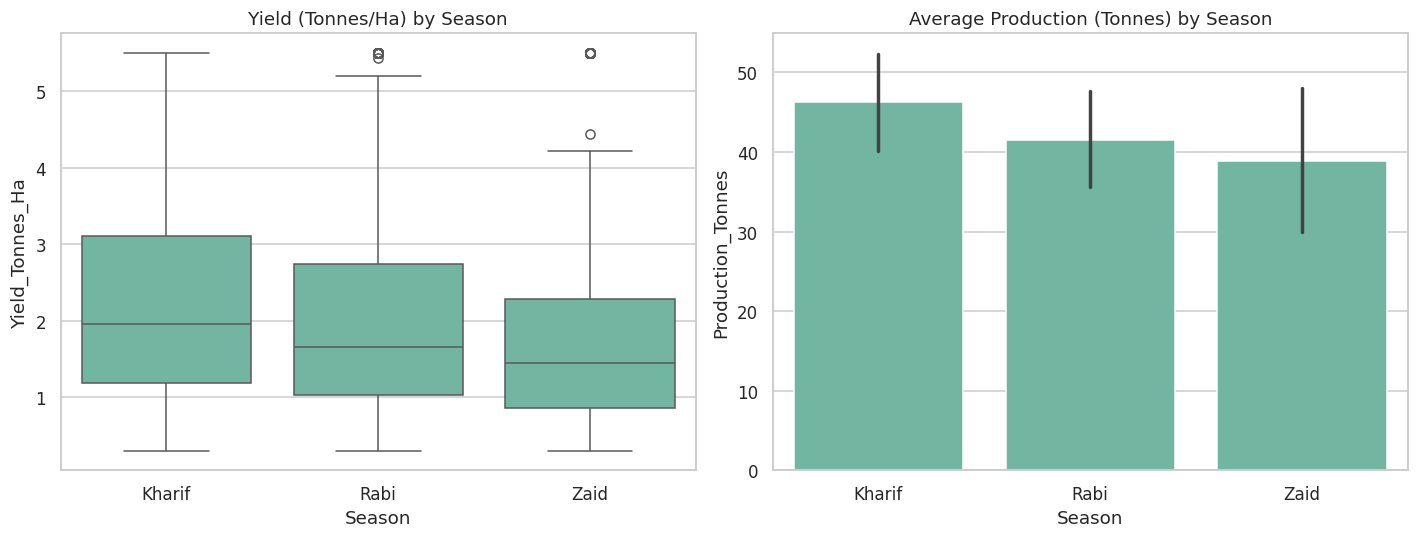

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, ax=axes[0])
axes[0].set_title('Yield (Tonnes/Ha) by Season')
sns.barplot(data=df, x='Season', y='Production_Tonnes', order=season_order, ax=axes[1], estimator=np.mean, errorbar=('ci', 95))
axes[1].set_title('Average Production (Tonnes) by Season')
plt.tight_layout()
plt.show()


In [12]:
perf_summary = df.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes']].agg(['mean','median','std']).reindex(season_order)
perf_summary


Yield_Tonnes_Ha                  Production_Tonnes                   
                  mean median       std              mean median         std
Season                                                                      
Kharif        2.253569   1.95  1.427579         46.311192  13.24  135.704677
Rabi          2.032950   1.66  1.396121         41.486712  11.08  121.904792
Zaid          1.805236   1.45  1.383699         38.886111   9.97  112.000668

**Observation:** Median yield and production differ across seasons; the boxplots reveal whether one season consistently outperforms the others or whether variability (spread) itself differs by season — a sign of less predictable seasonal conditions.

## 6. Statistical Test — Is the Seasonal Difference in Yield Significant?

In [13]:
groups = [df.loc[df['Season']==s, 'Yield_Tonnes_Ha'] for s in season_order]
f_stat, p_value = stats.f_oneway(*groups)
print(f"One-way ANOVA on Yield_Tonnes_Ha across seasons:")
print(f"F-statistic = {f_stat:.3f}, p-value = {p_value:.5f}")
if p_value < 0.05:
    print("=> Statistically significant difference in yield across seasons (p < 0.05).")
else:
    print("=> No statistically significant difference in yield across seasons (p >= 0.05).")


One-way ANOVA on Yield_Tonnes_Ha across seasons:
F-statistic = 25.422, p-value = 0.00000
=> Statistically significant difference in yield across seasons (p < 0.05).


ANOVA tests whether the mean yield is equal across the three seasons. A p-value below 0.05 indicates the seasonal differences observed are unlikely to be due to random chance alone.

## 7. Resource Usage Across Seasons

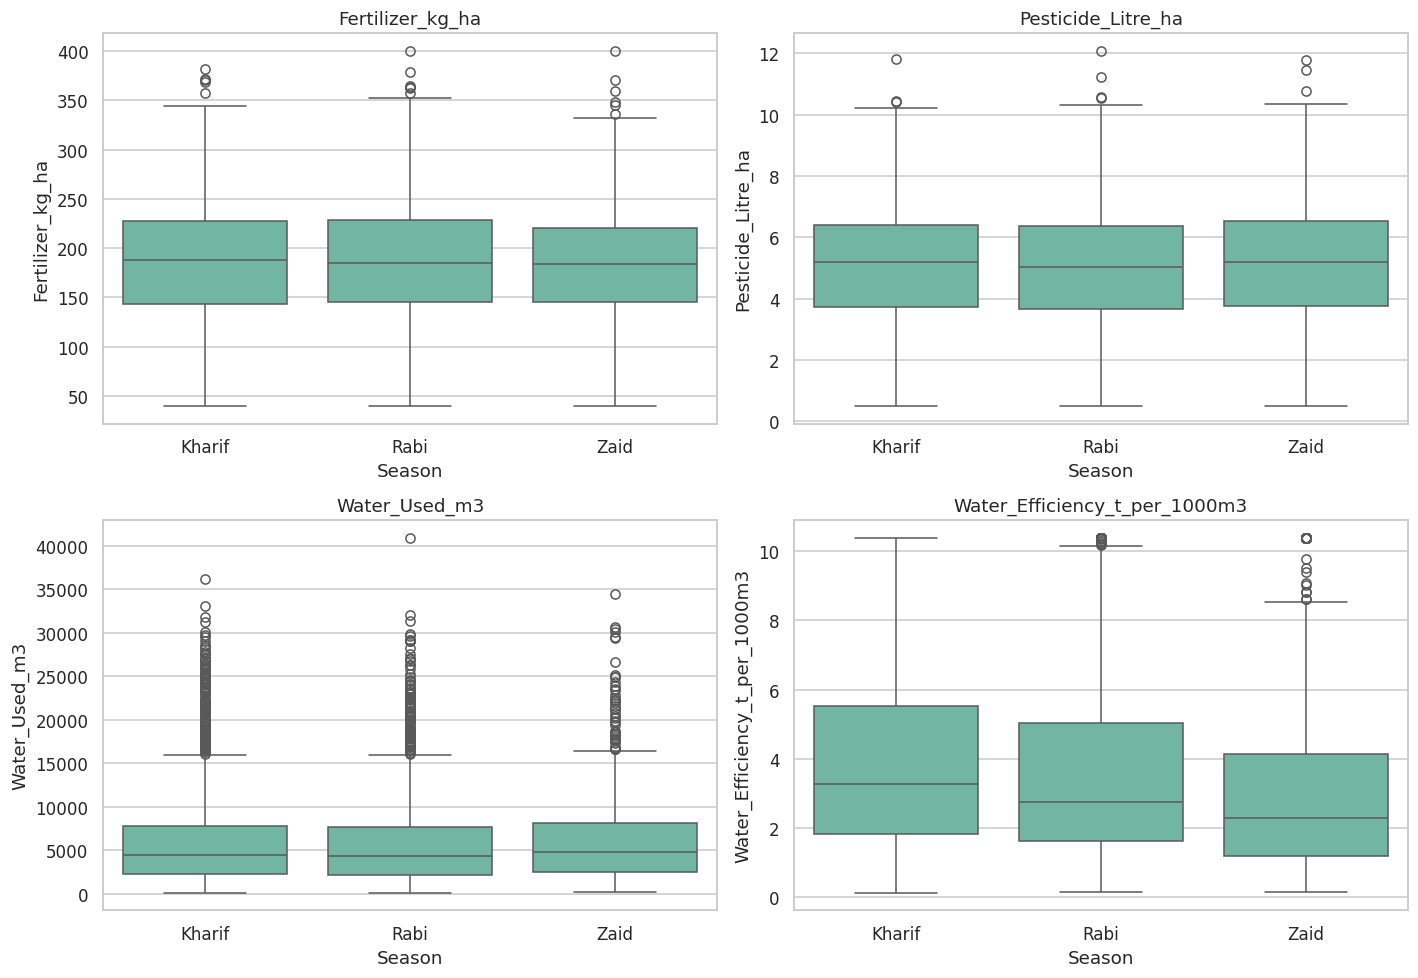

In [14]:
res_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(res_cols):
    sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


Irrigation method share (%) by season:
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             22.8   33.2     26.0       18.0
Rabi               22.7   32.3     26.9       18.0
Zaid               23.6   32.7     23.6       20.2


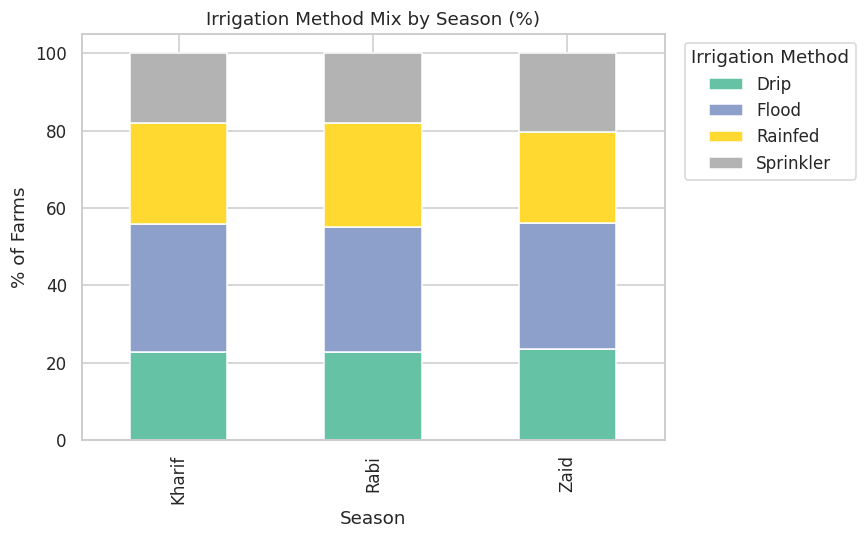

In [15]:
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').reindex(season_order) * 100
print("Irrigation method share (%) by season:")
print(irrigation_season.round(1))

irrigation_season.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set2')
plt.title('Irrigation Method Mix by Season (%)')
plt.ylabel('% of Farms')
plt.xlabel('Season')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Observation:** Water usage and water-use efficiency vary by season — typically Zaid (summer, low rainfall) relies more on irrigation and shows different efficiency than the monsoon-fed Kharif season. The irrigation-method mix shows which practices dominate in each season.

## 8. Economic Performance Across Seasons

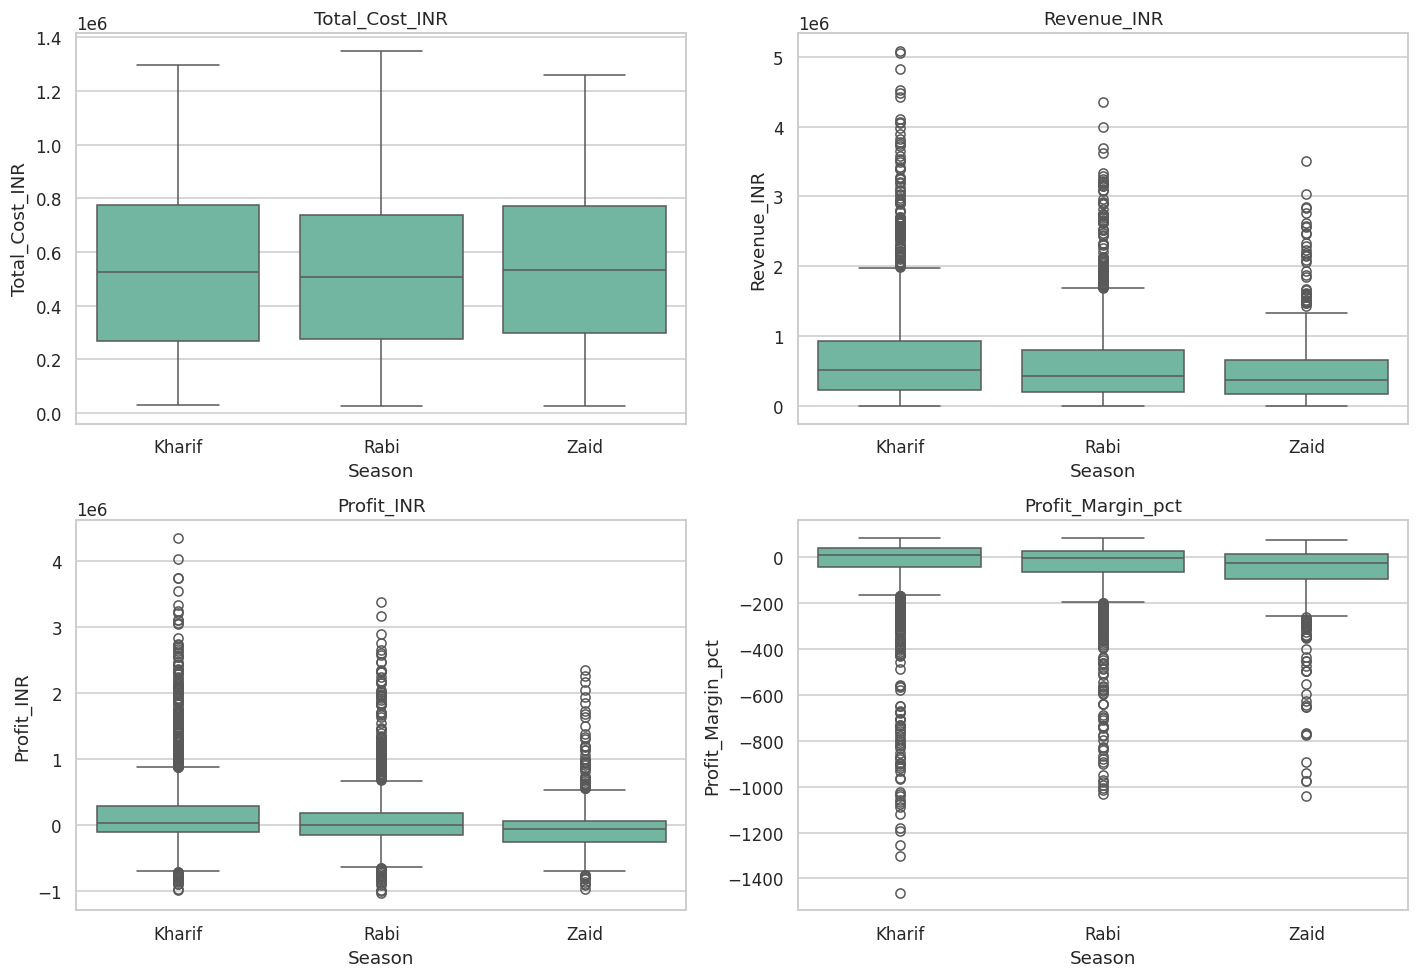

In [16]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(econ_cols):
    sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


In [17]:
econ_summary = df.groupby('Season')[econ_cols].mean().reindex(season_order).round(2)
econ_summary


,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.41,710719.06,178914.65,-38.64
Rabi,513836.58,601526.05,87689.47,-44.27
Zaid,543976.73,519171.90,-24804.82,-69.35


**Observation:** Comparing average cost, revenue, profit and profit margin by season shows which season is most economically efficient for farmers, and whether higher costs (e.g. more irrigation/fertilizer in Zaid) translate into proportionally higher revenue.

## 9. Disease/Pest Risk Across Seasons

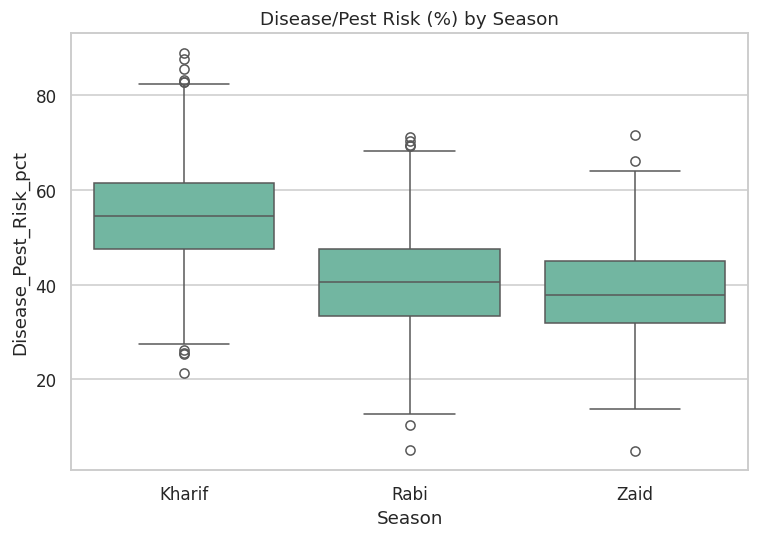

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=season_order)
plt.title('Disease/Pest Risk (%) by Season')
plt.tight_layout()
plt.show()

print(df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(season_order).round(2))


**Observation:** Higher humidity and rainfall seasons (typically Kharif) tend to show elevated disease/pest risk, consistent with agronomic expectations that moist, warm conditions favor pest and pathogen activity.

## 10. Correlation Analysis

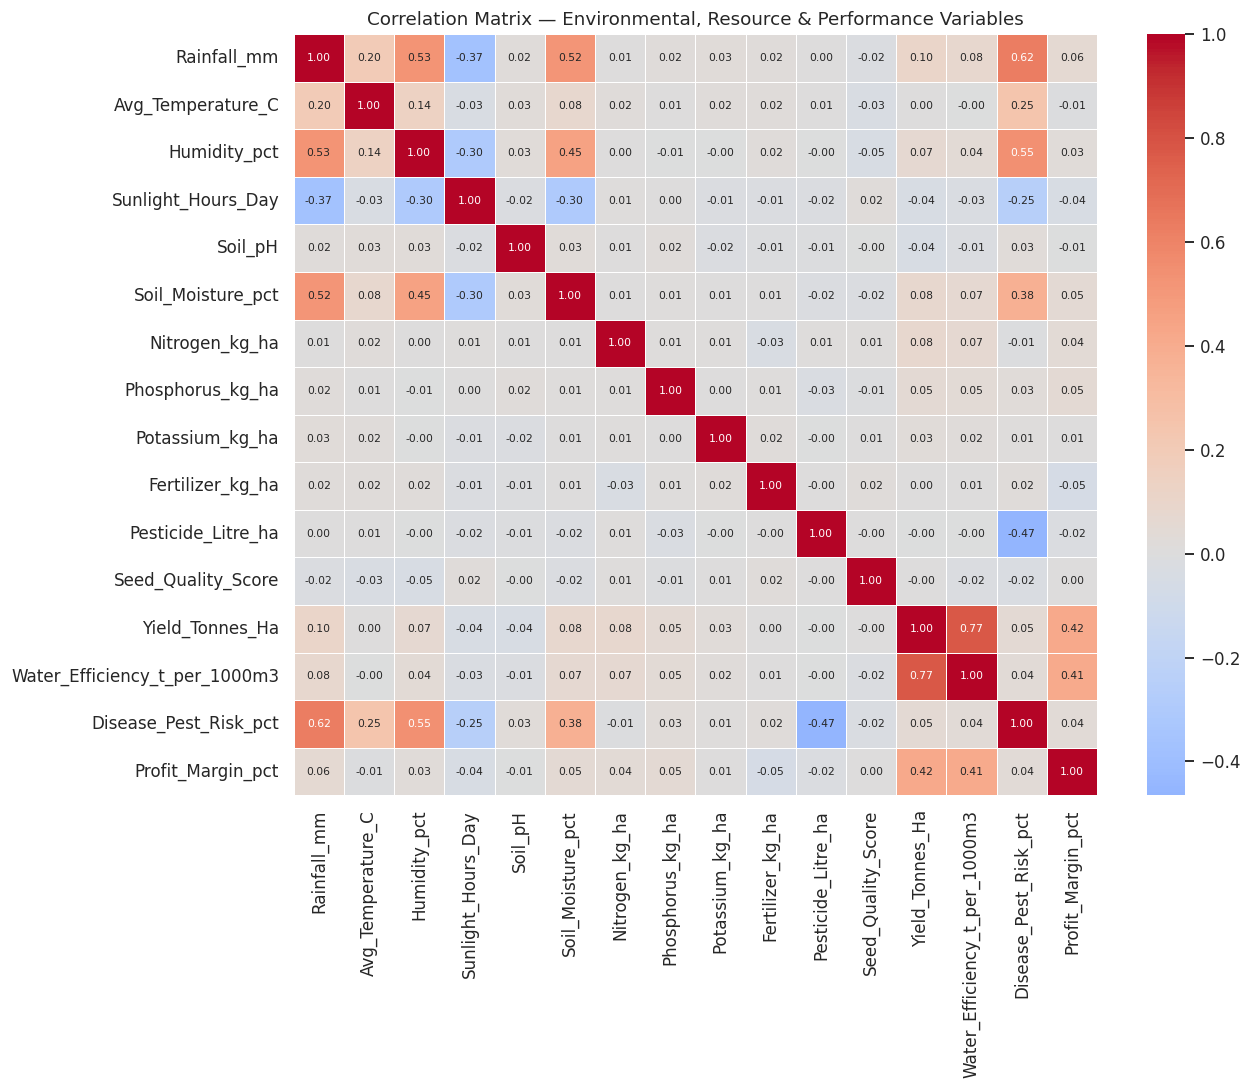

In [19]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
            'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Yield_Tonnes_Ha',
            'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Profit_Margin_pct']

corr = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.4, annot_kws={"size":7})
plt.title('Correlation Matrix — Environmental, Resource & Performance Variables')
plt.tight_layout()
plt.show()


In [20]:
print("Strongest correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False).drop('Yield_Tonnes_Ha').head(8))
print("\nStrongest correlations with Profit_Margin_pct:")
print(corr['Profit_Margin_pct'].sort_values(ascending=False).drop('Profit_Margin_pct').head(8))


Strongest correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.772986
Profit_Margin_pct                0.419005
Rainfall_mm                      0.102223
Soil_Moisture_pct                0.084191
Nitrogen_kg_ha                   0.080047
Humidity_pct                     0.065544
Phosphorus_kg_ha                 0.054219
Disease_Pest_Risk_pct            0.053701
Name: Yield_Tonnes_Ha, dtype: float64

Strongest correlations with Profit_Margin_pct:
Yield_Tonnes_Ha                  0.419005
Water_Efficiency_t_per_1000m3    0.407217
Rainfall_mm                      0.059975
Phosphorus_kg_ha                 0.052533
Soil_Moisture_pct                0.051688
Nitrogen_kg_ha                   0.040950
Disease_Pest_Risk_pct            0.037753
Humidity_pct                     0.028930
Name: Profit_Margin_pct, dtype: float64


**Observation:** The correlation matrix identifies which environmental and resource variables move together with yield and profitability most strongly, pointing to the factors most worth managing (e.g. seed quality, soil nutrients, irrigation) versus those with weak influence.

## 11. Seasonal Patterns Across Crops and States

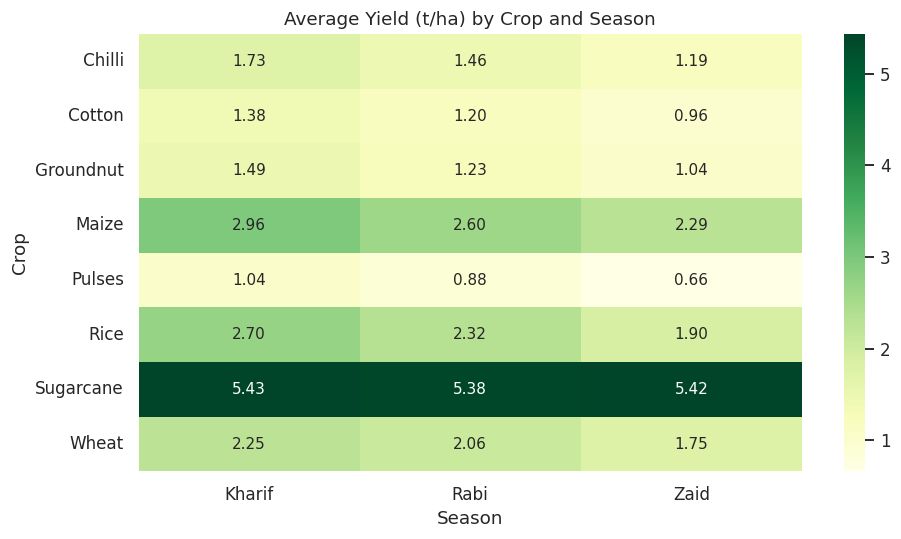

In [21]:
pivot_crop = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').reindex(columns=season_order)
plt.figure(figsize=(9,5))
sns.heatmap(pivot_crop.round(2), annot=True, cmap='YlGn', fmt='.2f')
plt.title('Average Yield (t/ha) by Crop and Season')
plt.tight_layout()
plt.show()


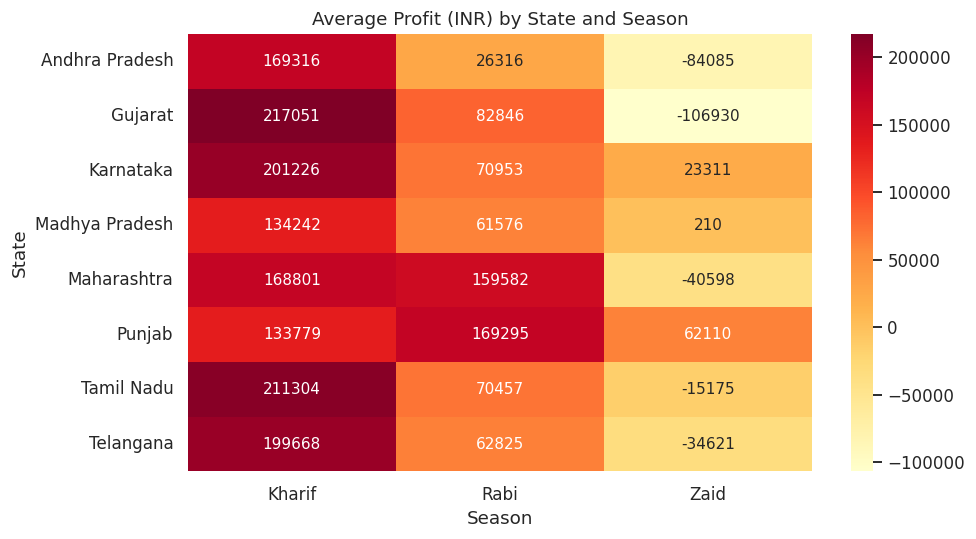

In [22]:
pivot_state = df.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean').reindex(columns=season_order)
plt.figure(figsize=(9,5))
sns.heatmap(pivot_state.round(0), annot=True, cmap='YlOrRd', fmt='.0f')
plt.title('Average Profit (INR) by State and Season')
plt.tight_layout()
plt.show()


**Observation:** These heatmaps test whether seasonal patterns are *consistent* across crops and regions or whether some crop/state combinations behave differently — directly answering one of the brief's key questions ("Are some seasonal patterns consistent across different regions or categories?").

## 12. Key Insights and Findings

Based on the analysis above:

1. **Seasonal yield differs measurably** — the ANOVA test confirms statistically significant variation in yield across Kharif, Rabi and Zaid, not just random noise.
2. **Environmental conditions drive the seasonal split** — Kharif's monsoon rainfall and humidity, Zaid's heat and dryness, and Rabi's moderate climate each create distinct growing conditions that show up directly in resource use and outcomes.
3. **Resource usage adapts to season** — irrigation intensity and method mix shift with rainfall availability, and water-use efficiency is not uniform across seasons.
4. **Economic performance is not simply proportional to cost** — some seasons carry higher input costs without a matching increase in profit margin, indicating an efficiency gap worth investigating further.
5. **Disease/pest risk rises with humidity and rainfall**, reinforcing the case for season-specific pest management planning.
6. **Yield and profitability correlate most strongly with a specific subset of variables** (see Section 10) rather than uniformly with all inputs — meaning targeted improvement in those factors would yield disproportionate benefit.
7. **Seasonal patterns are not perfectly uniform across crops and states**, so state- or crop-specific seasonal strategies would outperform a one-size-fits-all seasonal calendar.

## 13. Recommendations

- Prioritize the resource inputs most correlated with yield/profit (Section 10) rather than spreading investment evenly across all inputs.
- Align irrigation method choice with each season's rainfall profile to improve water-use efficiency, particularly in the driest season.
- Strengthen pest/disease monitoring specifically in the high-humidity season identified above.
- Use the crop × season and state × season heatmaps (Section 11) to guide season-specific crop selection at the regional level rather than a uniform national recommendation.
- Investigate the seasons/regions with high cost but low profit margin to identify avoidable inefficiencies.

## 14. Conclusion

This analysis shows that agricultural performance in this dataset varies meaningfully by season, driven by environmental conditions, resource usage patterns and their downstream effect on yield, disease/pest risk and profitability. The differences are statistically significant and vary further by crop and region, supporting season- and location-aware agricultural planning rather than a single generalized strategy.
